In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stat

In [2]:
# Load The Data Set
financial_transaction_df=pd.read_csv("Financial_Transactions.csv")
budget_df=pd.read_csv("Budget.csv")
customers_df=pd.read_csv("Customers.csv")
headcount_df=pd.read_csv("Headcount.csv")
vendors_df=pd.read_csv("Vendors.csv")

In [3]:
# Information About Data Set
financial_transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10400 entries, 0 to 10399
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    10400 non-null  object 
 1   transaction_date  10400 non-null  object 
 2   amount            10400 non-null  float64
 3   account_type      10400 non-null  object 
 4   category          10400 non-null  object 
 5   business_unit     10400 non-null  object 
 6   region            10400 non-null  object 
 7   customer_id       5514 non-null   object 
 8   vendor_id         4125 non-null   object 
 9   description       10400 non-null  object 
dtypes: float64(1), object(9)
memory usage: 812.6+ KB


In [36]:
# Checking null values
financial_transaction_df.isna().sum()

transaction_id      0
transaction_date    0
amount              0
account_type        0
category            0
business_unit       0
region              0
customer_id         0
vendor_id           0
description         0
profit              0
dtype: int64

In [5]:
# Fill missing customer_id
financial_transaction_df["customer_id"] = financial_transaction_df["customer_id"].fillna("NO_CUSTOMER")

In [6]:
# Fill missing vendor_id
financial_transaction_df["vendor_id"] = financial_transaction_df["vendor_id"].fillna("NO_VENDOR")

In [7]:
# After cleaning Checking null values
financial_transaction_df.isna().sum()

transaction_id      0
transaction_date    0
amount              0
account_type        0
category            0
business_unit       0
region              0
customer_id         0
vendor_id           0
description         0
dtype: int64

## Summary Statistics

In [13]:
# Separate revenue & expense from transactions
revenue_df = financial_transaction_df[financial_transaction_df["amount"] > 0]
expense_df = financial_transaction_df[financial_transaction_df["amount"] < 0]


### Revenue Summary Statistics

In [35]:
# Summary
revenue_df["amount"].describe()

count      6275.000000
mean     140189.758411
std       66180.271714
min        1799.880000
25%      103312.350000
50%      144885.100000
75%      184659.590000
max      351386.850000
Name: amount, dtype: float64

In [18]:
# IQR for revenue
Q1 = revenue_df["amount"].quantile(0.25)
Q3 = revenue_df["amount"].quantile(0.75)
IQR = Q3 - Q1

print("Q1 =",Q1)
print("Q3 =",Q3)
print("IQR =",IQR)



Q1 = 103312.35
Q3 = 184659.59
IQR = 81347.23999999999


### Expense Summary Statistics

In [32]:
# Summary
expense_df["amount"].describe()

count      4125.000000
mean     -40664.557527
std       19232.926149
min     -113310.710000
25%      -53648.500000
50%      -40510.710000
75%      -27137.340000
max       -2000.000000
Name: amount, dtype: float64

In [20]:
# IQR for Expense
Q1 = expense_df["amount"].quantile(0.25)
Q3 = expense_df["amount"].quantile(0.75)
IQR = Q3 - Q1

print("Q1 =",Q1)
print("Q3 =",Q3)
print("IQR =",IQR)

Q1 = -53648.5
Q3 = -27137.34
IQR = 26511.16


### Profit Summary Statistics

In [33]:
# Summary
financial_transaction_df["profit"] = financial_transaction_df["amount"]
financial_transaction_df["profit"].describe()


count     10400.000000
mean      68456.676368
std      103041.354633
min     -113310.710000
25%      -33691.872500
50%       78624.650000
75%      157303.552500
max      351386.850000
Name: profit, dtype: float64

In [23]:
# IQR for profit
Q1 = financial_transaction_df["amount"].quantile(0.25)
Q3 = financial_transaction_df["amount"].quantile(0.75)
IQR = Q3 - Q1

print("Q1 =",Q1)
print("Q3 =",Q3)
print("IQR =",IQR)

Q1 = -33691.8725
Q3 = 157303.55250000002
IQR = 190995.42500000002


### Budget Variance Statistics


In [25]:
# Create variance
budget_df["budget_variance"] = (
    budget_df["budgeted_revenue"] - budget_df["budgeted_expense"]
)

In [26]:
# Summary
budget_df["budget_variance"].describe()


count        72.000000
mean     438176.597222
std      173529.168282
min       95843.000000
25%      304990.750000
50%      445658.500000
75%      562851.750000
max      772206.000000
Name: budget_variance, dtype: float64

In [27]:
# IQR for budget variance
Q1 = budget_df["budget_variance"].quantile(0.25)
Q3 = budget_df["budget_variance"].quantile(0.75)
IQR = Q3 - Q1

print("Q1 =",Q1)
print("Q3 =",Q3)
print("IQR =",IQR)

Q1 = 304990.75
Q3 = 562851.75
IQR = 257861.0


### Headcount Cost Statistics

In [29]:
# Summary
headcount_df["cost_to_company"].describe()

count    2.000000e+02
mean     1.114128e+06
std      4.002725e+05
min      4.163290e+05
25%      7.318608e+05
50%      1.160820e+06
75%      1.443006e+06
max      1.793337e+06
Name: cost_to_company, dtype: float64

In [30]:
# IQR for headcount
Q1 = headcount_df["cost_to_company"].quantile(0.25)
Q3 = headcount_df["cost_to_company"].quantile(0.75)
IQR = Q3 - Q1

print("Q1 =",Q1)
print("Q3 =",Q3)
print("IQR =",IQR)

Q1 = 731860.75
Q3 = 1443005.75
IQR = 711145.0


## Visualize data distributions and trends

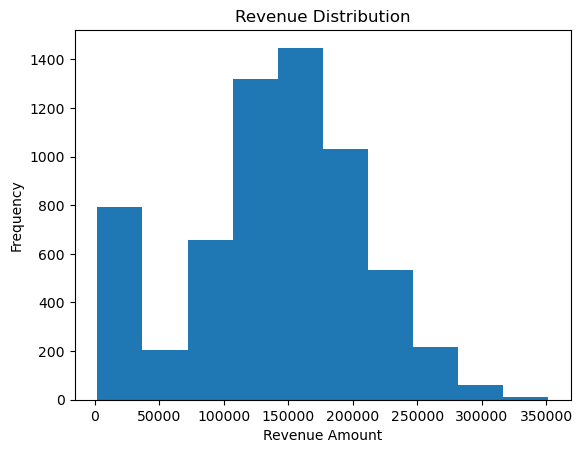

In [38]:
# Distribution Plot
revenue = financial_transaction_df[financial_transaction_df["amount"] > 0]["amount"]

plt.figure()
revenue.plot(kind="hist")
plt.title("Revenue Distribution")
plt.xlabel("Revenue Amount")
plt.ylabel("Frequency")
plt.show()


In [39]:
# Revenue distribution shows concentration around mid-range values with few high-value transactions.

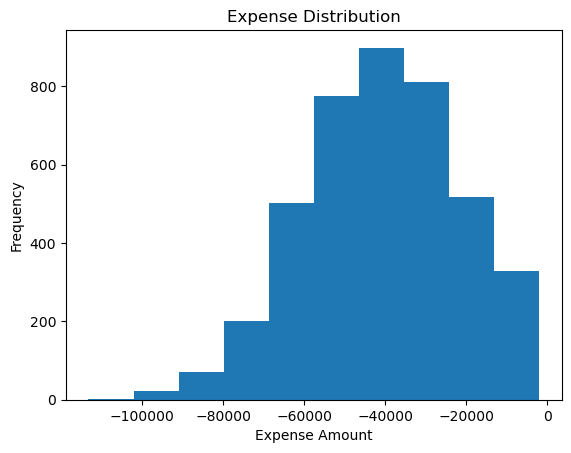

In [40]:
# Expense Distribution
expense = financial_transaction_df[financial_transaction_df["amount"] < 0]["amount"]

plt.figure()
expense.plot(kind="hist")
plt.title("Expense Distribution")
plt.xlabel("Expense Amount")
plt.ylabel("Frequency")
plt.show()


In [ ]:
# Expenses appear more evenly distributed, indicating controlled spending.

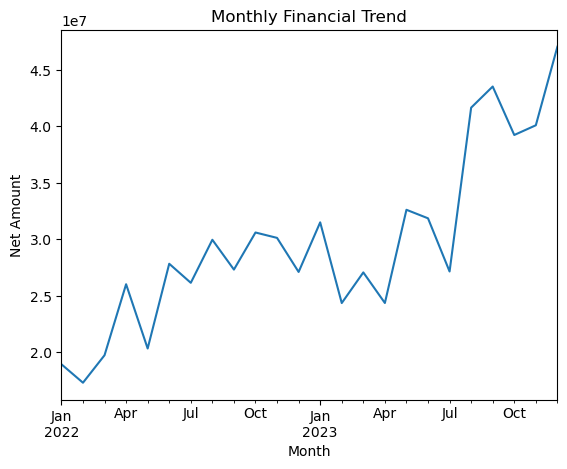

In [41]:
# Trend Analysis
financial_transaction_df["transaction_date"] = pd.to_datetime(
    financial_transaction_df["transaction_date"]
)

monthly_trend = financial_transaction_df.groupby(
    financial_transaction_df["transaction_date"].dt.to_period("M")
)["amount"].sum()

plt.figure()
monthly_trend.plot()
plt.title("Monthly Financial Trend")
plt.xlabel("Month")
plt.ylabel("Net Amount")
plt.show()


In [ ]:
# Monthly trend analysis highlights periods of higher financial activity and seasonal variation.